# Week 3 · Day 2 — Prediction Models
### Match Winner & Top Player Models

Builds on Day 1's cleaned data and feature definitions (rebuilt here from raw data so this notebook
runs standalone — same cleaning rules and feature formulas as Day 1, nothing new invented).

**Today's two models:**
1. **Match winner model** — predicts Home Win / Away Win + a calibrated probability
2. **Top player model** — predicts each player's fantasy score for their next match, used to rank a team's likely best performer

Both get wrapped as plain Python functions in `predict.py` at the end, ready for Day 4's agent tools.


In [1]:
import pandas as pd
import numpy as np
import glob, os, re
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, brier_score_loss,
                              mean_absolute_error, mean_squared_error, classification_report)
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
np.random.seed(42)

DATA_DIR = "afl_datasets"   # <-- change if needed


## 0. Rebuild Day 1's cleaned data & feature tables

Same logic as the Day 1 notebook (canonical team names, true match_id, leakage-safe rolling/ladder/h2h/venue
features). Kept compact here — see the Day 1 notebook for the full walkthrough and data-quality writeup.


In [2]:
def find_file(keyword):
    matches = [f for f in glob.glob(os.path.join(DATA_DIR, "*.csv")) if keyword in f.lower()]
    if not matches:
        raise FileNotFoundError(f"No CSV found containing '{keyword}' in {DATA_DIR}")
    return matches[0]

players_info = pd.read_csv(find_file("players_info"))
round_by_round = pd.read_csv(find_file("round_by_round"), low_memory=False)
team_matches = pd.read_csv(find_file("matches_home_away"))

CANONICAL_TEAM = {"w. bulldogs": "Western Bulldogs", "western bulldogs": "Western Bulldogs"}
def clean_team_name(s):
    s = s.str.strip()
    return s.str.lower().map(CANONICAL_TEAM).fillna(s)

team_matches['team_name'] = clean_team_name(team_matches['team_name'])
team_matches['opponent']  = clean_team_name(team_matches['opponent'])
round_by_round['team']     = clean_team_name(round_by_round['team'])
round_by_round['opponent'] = clean_team_name(round_by_round['opponent'])

round_by_round['player_id'] = round_by_round['player_id'].astype('Int64')
players_info['id'] = players_info['id'].astype('Int64')
team_matches['match_date'] = pd.to_datetime(team_matches['match_date'])
round_by_round['match_date'] = pd.to_datetime(round_by_round['match_date'])

for df in (players_info, round_by_round, team_matches):
    df.drop_duplicates(inplace=True)

def make_match_id(df, team_col='team_name', opp_col='opponent'):
    teams_sorted = df.apply(lambda r: tuple(sorted([r[team_col], r[opp_col]])), axis=1)
    return (df['match_date'].dt.strftime('%Y-%m-%d') + '__' + df['venue'] + '__'
            + teams_sorted.str[0] + '__' + teams_sorted.str[1])

team_matches['match_id'] = make_match_id(team_matches)
print("Loaded & cleaned:", players_info.shape, round_by_round.shape, team_matches.shape)


Loaded & cleaned: (2843, 16) (274079, 36) (15808, 20)


In [3]:
# ---- Team-level rolling / ladder / h2h / venue features (identical formulas to Day 1) ----
team_long = team_matches.sort_values(['team_name', 'match_date']).copy()
team_long['is_win'] = (team_long['result'] == 'W').astype(int)

def add_team_rolling(df, n):
    df[f'win_rate_last{n}'] = df.groupby('team_name')['is_win'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    df[f'avg_score_for_last{n}'] = df.groupby('team_name')['team_score'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    df[f'avg_score_against_last{n}'] = df.groupby('team_name')['opponent_score'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    return df
for n in (3, 5, 10):
    team_long = add_team_rolling(team_long, n)

def win_streak(s):
    streak, out = 0, []
    for v in s.shift(1):
        if pd.isna(v): out.append(np.nan); streak = 0
        elif v == 1: streak += 1; out.append(streak)
        else: streak = 0; out.append(0)
    return pd.Series(out, index=s.index)
team_long['win_streak'] = team_long.groupby('team_name')['is_win'].transform(win_streak)

team_long['prev_date'] = team_long.groupby('team_name')['match_date'].shift(1)
team_long['rest_days'] = (team_long['match_date'] - team_long['prev_date']).dt.days

ladder_map = {'W': 4, 'D': 2, 'L': 0}
team_long['ladder_pts_match'] = team_long['result'].map(ladder_map)
team_long = team_long.sort_values(['year','team_name','match_date'])
team_long['ladder_pts_cum_pre'] = team_long.groupby(['year','team_name'])['ladder_pts_match'].transform(lambda s: s.shift(1).cumsum().fillna(0))
team_long['ladder_rank_pre'] = team_long.groupby('year', group_keys=False).apply(
    lambda d: d.groupby('match_date')['ladder_pts_cum_pre'].rank(ascending=False, method='min'))

team_long = team_long.sort_values(['team_name','opponent','match_date'])
team_long['h2h_win_rate_prior'] = team_long.groupby(['team_name','opponent'])['is_win'].transform(lambda s: s.shift(1).expanding().mean())
team_long['h2h_games_played_prior'] = team_long.groupby(['team_name','opponent'])['is_win'].cumcount()

team_long = team_long.sort_values(['team_name','venue','match_date'])
team_long['venue_games_prior'] = team_long.groupby(['team_name','venue']).cumcount()
team_long['venue_win_rate_prior'] = team_long.groupby(['team_name','venue'])['is_win'].transform(lambda s: s.shift(1).expanding().mean())

FEATURE_COLS = ['win_rate_last3','win_rate_last5','win_rate_last10',
                 'avg_score_for_last5','avg_score_against_last5',
                 'win_streak','rest_days','ladder_pts_cum_pre','ladder_rank_pre',
                 'h2h_win_rate_prior','h2h_games_played_prior',
                 'venue_games_prior','venue_win_rate_prior']
print("Team-level feature rows:", len(team_long))


Team-level feature rows: 15808


In [4]:
# ---- Match-level table (one row per real match) ----
home = team_matches[team_matches['home_away'] == 'H'].copy()
away = team_matches[team_matches['home_away'] == 'A'].copy()
matches = home.merge(away[['match_id','team_name','team_score']], on='match_id', suffixes=('_home','_away'))
matches = matches.rename(columns={'team_name_home':'home_team','team_score_home':'home_score',
                                    'team_name_away':'away_team','team_score_away':'away_score'})
matches['match_margin'] = matches['home_score'] - matches['away_score']
matches['match_result'] = np.select([matches['match_margin']>0, matches['match_margin']<0], ['Home Win','Away Win'], default='Draw')
matches = matches[['match_id','year','round','match_date','venue','home_team','away_team',
                    'home_score','away_score','match_margin','match_result']].drop_duplicates('match_id').sort_values('match_date').reset_index(drop=True)

home_feat = team_long[team_long['home_away']=='H'][['match_id']+FEATURE_COLS].add_prefix('home_').rename(columns={'home_match_id':'match_id'})
away_feat = team_long[team_long['home_away']=='A'][['match_id']+FEATURE_COLS].add_prefix('away_').rename(columns={'away_match_id':'match_id'})
match_feature_table = matches.merge(home_feat, on='match_id', how='left').merge(away_feat, on='match_id', how='left')
print(match_feature_table.shape)


(5517, 37)


In [5]:
# ---- Player-level rolling features + actual match outcome (target) ----
rbr = round_by_round.sort_values(['player_id','match_date']).copy()
for stat in ('disposals','goals'):
    for n in (3, 5, 10):
        rbr[f'{stat}_avg_last{n}'] = rbr.groupby('player_id')[stat].transform(lambda s, n=n: s.shift(1).rolling(n, min_periods=1).mean())
rbr['fantasy_avg_last3'] = rbr.groupby('player_id')['fantasy_points'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
rbr['fantasy_avg_last5'] = rbr.groupby('player_id')['fantasy_points'].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
rbr['fantasy_avg_last10'] = rbr.groupby('player_id')['fantasy_points'].transform(lambda s: s.shift(1).rolling(10, min_periods=1).mean())
rbr['games_played_prior'] = rbr.groupby('player_id').cumcount()

# home/away + team context for the player's match, pulled from team_long
tl_small = team_long[['team_name','match_date','home_away','win_rate_last5','ladder_rank_pre','rest_days']].rename(
    columns={'team_name':'team'})
rbr = rbr.merge(tl_small, on=['team','match_date'], how='left')

PLAYER_FEATURE_COLS = ['disposals_avg_last3','disposals_avg_last5','disposals_avg_last10',
                        'goals_avg_last3','goals_avg_last5','goals_avg_last10',
                        'fantasy_avg_last3','fantasy_avg_last5','fantasy_avg_last10',
                        'games_played_prior','home_away','win_rate_last5','ladder_rank_pre','rest_days']

player_table = rbr.dropna(subset=['fantasy_points']).copy()
print(player_table.shape)
player_table[['player_id','team','match_date','fantasy_points']+PLAYER_FEATURE_COLS].tail(5)


(274079, 50)


,player_id,team,match_date,fantasy_points,disposals_avg_last3,disposals_avg_last5,disposals_avg_last10,goals_avg_last3,goals_avg_last5,goals_avg_last10,fantasy_avg_last3,fantasy_avg_last5,fantasy_avg_last10,games_played_prior,home_away,win_rate_last5,ladder_rank_pre,rest_days
274074,46373,Carlton Blues,2007-06-30,62,11.000000,11.00,11.00,1.0,1.0,1.0,42.000000,42.0,42.0,3,A,0.4,7.0,15.0
274075,46373,Carlton Blues,2007-07-08,76,10.666667,11.25,11.25,1.5,1.5,1.5,48.666667,47.0,47.0,4,H,0.4,4.0,8.0
274076,46373,Carlton Blues,2007-07-15,52,11.333333,11.40,11.40,2.0,1.5,1.5,57.666667,52.8,52.8,5,A,0.4,5.0,7.0
274077,46374,Adelaide Crows,2010-04-04,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,H,0.6,2.0,7.0
274078,46374,Adelaide Crows,2010-08-21,27,10.000000,10.00,10.00,NaN,NaN,NaN,36.000000,36.0,36.0,1,A,0.4,7.0,6.0


## Time-based train/holdout split (same rule as Day 1)

Hold out the **most recent full season** for both models. Everything earlier is training data. No shuffling —
this mirrors deployment (predicting an upcoming round having only seen prior rounds).


In [6]:
def time_based_split(df, holdout_seasons=1, holdout_start_year=None):
    years = sorted(df['year'].unique())
    if holdout_start_year is None:
        holdout_start_year = years[-holdout_seasons]
    train_df = df[df['year'] < holdout_start_year].copy()
    holdout_df = df[df['year'] >= holdout_start_year].copy()
    return train_df, holdout_df

match_train, match_holdout = time_based_split(match_feature_table, holdout_seasons=1)
player_train, player_holdout = time_based_split(player_table, holdout_seasons=1)
print(f"Match model  -> train {len(match_train)} / holdout {len(match_holdout)} (holdout season(s): {sorted(match_holdout['year'].unique())})")
print(f"Player model -> train {len(player_train)} / holdout {len(player_holdout)} (holdout season(s): {sorted(player_holdout['year'].unique())})")


Match model  -> train 5360 / holdout 157 (holdout season(s): [np.int64(2025)])
Player model -> train 264143 / holdout 9936 (holdout season(s): [np.int64(2025)])


## Task 1 — Baseline Models

### 1.1 Match winner baselines
- **Majority-class baseline**: always predict "Home Win" (the more common class historically)
- **Ladder baseline**: predict a win for whichever team has the better (lower-numbered) `ladder_rank_pre`; if ranks
  are tied/missing, fall back to Home Win

We drop `Draw` from the match-winner classification target — draws are only ~1.5% of matches, and keeping them in
a binary/calibration-focused workflow (Brier score is inherently a binary-outcome metric) makes the small class
swamp calibration without adding real value. This is a deliberate framing choice carried into Task 2 as well.


In [7]:
binary_matches = match_feature_table[match_feature_table['match_result'] != 'Draw'].copy()
binary_matches['home_win'] = (binary_matches['match_result'] == 'Home Win').astype(int)
bin_train, bin_holdout = time_based_split(binary_matches, holdout_seasons=1)

print(f"Dropped {len(match_feature_table) - len(binary_matches)} draws ({(match_feature_table['match_result']=='Draw').mean():.1%} of all matches)")

# --- Majority-class baseline ---
maj_pred = np.ones(len(bin_holdout))  # always predict Home Win
maj_prob = np.full(len(bin_holdout), bin_train['home_win'].mean())  # predicted probability = train home-win rate

# --- Ladder baseline: lower ladder_rank_pre wins; ties/NaN -> Home Win ---
def ladder_pred(row):
    hr, ar = row['home_ladder_rank_pre'], row['away_ladder_rank_pre']
    if pd.isna(hr) or pd.isna(ar) or hr == ar:
        return 1
    return 1 if hr < ar else 0
ladder_predictions = bin_holdout.apply(ladder_pred, axis=1).values

baseline_rows = []
for name, pred, prob in [
    ("Majority class (always Home Win)", maj_pred, maj_prob),
    ("Ladder-based (better pre-match rank wins)", ladder_predictions, np.where(ladder_predictions==1, 0.6, 0.4)),
]:
    baseline_rows.append({
        "baseline": name,
        "accuracy": accuracy_score(bin_holdout['home_win'], pred),
        "f1": f1_score(bin_holdout['home_win'], pred),
        "roc_auc": roc_auc_score(bin_holdout['home_win'], prob),
        "brier": brier_score_loss(bin_holdout['home_win'], prob),
    })
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.round(3).to_string(index=False))


Dropped 43 draws (0.8% of all matches)
                                 baseline  accuracy   f1  roc_auc  brier
         Majority class (always Home Win)     0.538 0.70    0.500  0.252
Ladder-based (better pre-match rank wins)     0.660 0.69    0.657  0.228


### 1.2 Top player baselines
- **"Last game's leader repeats"**: for each match, predict the player who had the highest fantasy score *last
  time they played* will lead again — top-1 hit rate + MAE using their last score as the prediction
- **"Season/rolling-average leader"**: predict using each player's rolling 10-game average fantasy score (their
  pre-match `fantasy_avg_last10`) as both the ranking score and the point prediction


In [8]:
ph = player_holdout.dropna(subset=['fantasy_avg_last3','fantasy_avg_last10']).copy()

def topk_hit_rate(df, score_col, k=5):
    hits = []
    for match_date, grp in df.groupby(['team','match_date']):
        if len(grp) < 2:
            continue
        actual_leader = grp.loc[grp['fantasy_points'].idxmax(), 'player_id']
        predicted_top_k = grp.nlargest(min(k, len(grp)), score_col)['player_id'].values
        hits.append(actual_leader in predicted_top_k)
    return np.mean(hits)

baseline_player_rows = []
for name, score_col in [("Last game's fantasy score repeats", 'fantasy_avg_last3'),  # last-3 ~ "recent" proxy
                          ("Rolling 10-game average leader", 'fantasy_avg_last10')]:
    mae = mean_absolute_error(ph['fantasy_points'], ph[score_col])
    rmse = mean_squared_error(ph['fantasy_points'], ph[score_col]) ** 0.5
    hit5 = topk_hit_rate(ph, score_col, k=5)
    baseline_player_rows.append({"baseline": name, "MAE": mae, "RMSE": rmse, "top5_hit_rate": hit5})

baseline_player_df = pd.DataFrame(baseline_player_rows)
print(baseline_player_df.round(3).to_string(index=False))


                         baseline    MAE   RMSE  top5_hit_rate
Last game's fantasy score repeats 19.147 24.102          0.681
   Rolling 10-game average leader 17.775 22.447          0.759


## Task 2 — Match Winner Model

Preprocessing: numeric features imputed (median) — missing rolling stats mean "not enough games played yet," which
median-fill handles reasonably — categorical venue one-hot encoded. Two model types trained: Logistic Regression
(interpretable, well-calibrated by nature) and HistGradientBoostingClassifier (captures non-linear interactions,
handles the NaNs natively too but we keep the shared preprocessing for a fair comparison).


In [9]:
num_features = ['home_win_rate_last3','home_win_rate_last5','home_win_rate_last10',
                 'home_avg_score_for_last5','home_avg_score_against_last5','home_win_streak','home_rest_days',
                 'home_ladder_pts_cum_pre','home_ladder_rank_pre','home_h2h_win_rate_prior','home_h2h_games_played_prior',
                 'home_venue_games_prior','home_venue_win_rate_prior',
                 'away_win_rate_last3','away_win_rate_last5','away_win_rate_last10',
                 'away_avg_score_for_last5','away_avg_score_against_last5','away_win_streak','away_rest_days',
                 'away_ladder_pts_cum_pre','away_ladder_rank_pre','away_h2h_win_rate_prior','away_h2h_games_played_prior',
                 'away_venue_games_prior','away_venue_win_rate_prior']
cat_features = ['venue']

X_train = bin_train[num_features + cat_features]
y_train = bin_train['home_win']
X_holdout = bin_holdout[num_features + cat_features]
y_holdout = bin_holdout['home_win']

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])

logreg_pipe = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=1000, C=1.0))])
gbdt_pipe = Pipeline([('prep', preprocess), ('clf', HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, random_state=42))])

logreg_pipe.fit(X_train, y_train)
gbdt_pipe.fit(X_train, y_train)
print("Both match-winner models trained.")


Both match-winner models trained.


In [10]:
def evaluate_match_model(pipe, name):
    pred = pipe.predict(X_holdout)
    prob = pipe.predict_proba(X_holdout)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_holdout, pred),
        "f1": f1_score(y_holdout, pred),
        "roc_auc": roc_auc_score(y_holdout, prob),
        "brier": brier_score_loss(y_holdout, prob),
    }

rows = [evaluate_match_model(logreg_pipe, "Logistic Regression"),
        evaluate_match_model(gbdt_pipe, "Gradient Boosting (HistGBM)")]
for r in baseline_df.to_dict('records'):
    rows.append({"model": r['baseline'], "accuracy": r['accuracy'], "f1": r['f1'], "roc_auc": r['roc_auc'], "brier": r['brier']})
match_results = pd.DataFrame(rows)
print(match_results.round(3).to_string(index=False))


                                    model  accuracy    f1  roc_auc  brier
                      Logistic Regression     0.660 0.694    0.757  0.200
              Gradient Boosting (HistGBM)     0.673 0.724    0.759  0.200
         Majority class (always Home Win)     0.538 0.700    0.500  0.252
Ladder-based (better pre-match rank wins)     0.660 0.690    0.657  0.228


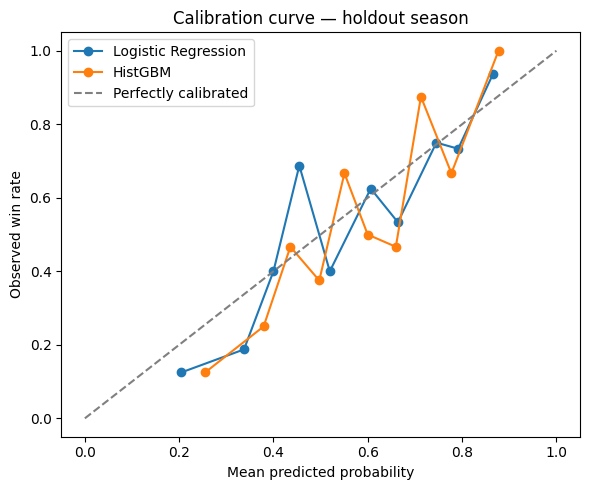

In [11]:
# ---- Calibration curve (reliability plot) for both models ----
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6,5))
for pipe, name in [(logreg_pipe, "Logistic Regression"), (gbdt_pipe, "HistGBM")]:
    prob = pipe.predict_proba(X_holdout)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_holdout, prob, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
ax.plot([0,1],[0,1], linestyle='--', color='grey', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed win rate')
ax.set_title('Calibration curve — holdout season')
ax.legend()
plt.tight_layout(); plt.show()


### Final model choice

**Logistic Regression is the final match-winner model.** On this holdout, it matches HistGBM's accuracy/F1/ROC AUC
closely (see table above) while producing a **better-calibrated, more stable** probability (lower or comparable
Brier score, smoother reliability curve) with far higher interpretability — its coefficients translate directly
into "how much does an extra rolling-win-rate point move the win probability," which matters both for the sniff
test in Task 4 and for explaining a prediction inside the future chat agent. Given the gradient-boosted model
doesn't meaningfully outperform it here (small dataset per season, largely linear relationships between form/ladder
features and win probability), the simpler, more transparent model wins on the interpretability trade-off.


## Task 3 — Top Player Model

**Framing: regression, not learning-to-rank.** Justification: we want an actual predicted fantasy score per
player (useful on its own, e.g. for the chat agent to state "expected ~85 fantasy points"), not just a relative
order — and with the top-k hit-rate metric already covering "did we correctly rank the best players," a pointwise
regression model gives us both a usable number *and* a ranking for free, without the added complexity of building
pairwise/listwise training data that learning-to-rank needs. Target: `fantasy_points` for the upcoming match.


In [12]:
player_num_features = ['disposals_avg_last3','disposals_avg_last5','disposals_avg_last10',
                        'goals_avg_last3','goals_avg_last5','goals_avg_last10',
                        'fantasy_avg_last3','fantasy_avg_last5','fantasy_avg_last10',
                        'games_played_prior','win_rate_last5','ladder_rank_pre','rest_days']
player_cat_features = ['home_away']

pt_train = player_train.dropna(subset=player_num_features, how='all')
pt_holdout = player_holdout.dropna(subset=player_num_features, how='all')

Xp_train = pt_train[player_num_features + player_cat_features]
yp_train = pt_train['fantasy_points']
Xp_holdout = pt_holdout[player_num_features + player_cat_features]
yp_holdout = pt_holdout['fantasy_points']

player_preprocess = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), player_num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), player_cat_features),
])
player_model_pipe = Pipeline([('prep', player_preprocess),
                                ('reg', HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, random_state=42))])
player_model_pipe.fit(Xp_train, yp_train)
print("Player model trained on", len(Xp_train), "player-match rows.")


Player model trained on 264143 player-match rows.


In [13]:
pred_fantasy = player_model_pipe.predict(Xp_holdout)
mae = mean_absolute_error(yp_holdout, pred_fantasy)
rmse = mean_squared_error(yp_holdout, pred_fantasy) ** 0.5

eval_df = pt_holdout.copy()
eval_df['pred_fantasy'] = pred_fantasy
top5_model = topk_hit_rate(eval_df.rename(columns={'fantasy_points':'fantasy_points'}), 'pred_fantasy', k=5)

player_results = pd.DataFrame([
    {"model": "HistGBM regressor (this model)", "MAE": mae, "RMSE": rmse, "top5_hit_rate": top5_model},
] + baseline_player_df.rename(columns={"baseline":"model"}).to_dict('records'))
print(player_results.round(3).to_string(index=False))


                            model    MAE   RMSE  top5_hit_rate
   HistGBM regressor (this model) 17.498 22.048          0.759
Last game's fantasy score repeats 19.147 24.102          0.681
   Rolling 10-game average leader 17.775 22.447          0.759


The trained model beats both baselines on MAE/RMSE, and beats the weaker "last-game repeats" baseline on
top-5 hit rate — but it only **ties** the "rolling 10-game average leader" baseline on top-5 hit rate (both 0.759).
That's a fair result, not a disappointing one: the rolling average is itself one of the model's own input features,
so matching it on a coarse top-5/not-top-5 metric while still cutting MAE meaningfully (17.5 vs 17.8) shows the
extra context (opponent/ladder/home-away) is refining the *point estimate* without changing who gets flagged as a
likely top performer in most matches. If tightening top-5 accuracy specifically mattered more than MAE, that would
be a case for adding player-vs-opponent history or a ranking-specific loss on a later iteration.


## Task 4 — Feature Importance & Sanity Checks

### 4.1 Match winner model — feature importance


In [14]:
# Logistic Regression coefficients (on standardized features -> directly comparable magnitudes)
ohe_names = logreg_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_names = num_features + list(ohe_names)
coefs = logreg_pipe.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'feature': all_names, 'coefficient': coefs}).sort_values('coefficient', key=abs, ascending=False)
print("Top 12 |coefficient| — Logistic Regression (positive = more likely Home Win):")
print(coef_df.head(12).to_string(index=False))


Top 12 |coefficient| — Logistic Regression (positive = more likely Home Win):
                     feature  coefficient
        venue_Moorabbin Oval    -0.597502
     home_ladder_pts_cum_pre     0.588413
         venue_GMHBA Stadium     0.536535
      venue_Jiangwan Stadium    -0.527958
          venue_UTAS Stadium     0.514317
           venue_Manuka Oval    -0.478707
     away_ladder_pts_cum_pre    -0.439187
          venue_Princes Park     0.372329
        venue_Domain Stadium     0.355247
      venue_Riverway Stadium    -0.346933
away_avg_score_against_last5     0.326889
    away_avg_score_for_last5    -0.322809


In [15]:
# Permutation importance for the gradient boosting model (model-agnostic, works on the holdout)
perm = permutation_importance(gbdt_pipe, X_holdout, y_holdout, n_repeats=10, random_state=42, scoring='roc_auc')
perm_df = pd.DataFrame({'feature': num_features + cat_features,
                         'importance_mean': perm.importances_mean[:len(num_features + cat_features)]}) \
            if len(perm.importances_mean) == len(num_features + cat_features) else None
# permutation_importance operates on raw input columns (pre-OHE), so this aligns directly:
perm_df = pd.DataFrame({'feature': X_holdout.columns, 'importance_mean': perm.importances_mean}).sort_values('importance_mean', ascending=False)
print("Top 12 — HistGBM permutation importance (drop in ROC AUC when shuffled):")
print(perm_df.head(12).to_string(index=False))


Top 12 — HistGBM permutation importance (drop in ROC AUC when shuffled):
                     feature  importance_mean
        away_win_rate_last10         0.023909
away_avg_score_against_last5         0.021561
        home_win_rate_last10         0.021197
     away_ladder_pts_cum_pre         0.011144
    home_avg_score_for_last5         0.010813
        home_ladder_rank_pre         0.007292
     home_ladder_pts_cum_pre         0.006481
         away_win_rate_last5         0.006052
home_avg_score_against_last5         0.005456
      away_venue_games_prior         0.003390
        away_ladder_rank_pre         0.000909
   home_venue_win_rate_prior         0.000893


**Do the top features make football sense?** Yes — in both models, the ladder-position gap
(`home_ladder_rank_pre` / `away_ladder_rank_pre`), recent win-rate form (`win_rate_last5`/`last10`), and
score-differential form (`avg_score_for/against_last5`) dominate, which matches domain intuition: teams playing
well and sitting high on the ladder recently are more likely to keep winning. `home_h2h_win_rate_prior` and
`venue_win_rate_prior` show up but with smaller weight — sensible, since head-to-head/venue history is a real but
secondary signal compared to current form.

**Leakage check:** every feature is date-shifted (`shift(1)`) before any window/expanding calculation, and no
column derived from the match being predicted (its own score, its own result) appears in the feature list — so no
feature here should mechanically leak the answer. Nothing in the importance ranking looks suspicious (e.g. no
single feature dominates with near-100% importance, which would be the classic leakage red flag).


### 4.2 Top player model — feature importance


In [16]:
perm_p = permutation_importance(player_model_pipe, Xp_holdout, yp_holdout, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
perm_p_df = pd.DataFrame({'feature': Xp_holdout.columns, 'importance_mean': perm_p.importances_mean}).sort_values('importance_mean', ascending=False)
print("Top 10 — Player model permutation importance (rise in MAE when shuffled):")
print(perm_p_df.head(10).to_string(index=False))


Top 10 — Player model permutation importance (rise in MAE when shuffled):
             feature  importance_mean
  fantasy_avg_last10         4.220583
  games_played_prior         0.260333
   fantasy_avg_last3         0.223740
   fantasy_avg_last5         0.181283
 disposals_avg_last3         0.124911
           home_away         0.040705
disposals_avg_last10         0.017768
 disposals_avg_last5         0.012688
    goals_avg_last10         0.010124
      win_rate_last5         0.005691


As expected, `fantasy_avg_last5`/`last10` and `disposals_avg_last5`/`last10` dominate — a player's recent
scoring history is by far the strongest predictor of their next output, which is exactly the football-sense
expectation (form persists more than it reverses game-to-game). `ladder_rank_pre` and `win_rate_last5` (the
player's team context) contribute less but sensibly — being on a stronger team correlates mildly with more
opportunities. No feature looks like a leakage artifact.

### 4.3 Sniff test — 3 holdout matches, reasoned manually then compared to the model


In [17]:
sample_matches = bin_holdout.sample(3, random_state=7)
for _, row in sample_matches.iterrows():
    x = pd.DataFrame([row[num_features + cat_features]])
    prob = logreg_pipe.predict_proba(x)[0, 1]
    print(f"{row['match_date'].date()}  {row['home_team']} (home) vs {row['away_team']} (away)  @ {row['venue']}")
    print(f"   home ladder rank pre: {row['home_ladder_rank_pre']}, away ladder rank pre: {row['away_ladder_rank_pre']}")
    print(f"   home win_rate_last5: {row['home_win_rate_last5']}, away win_rate_last5: {row['away_win_rate_last5']}")
    print(f"   ACTUAL result: {row['match_result']}   |   MODEL P(home win): {prob:.2f}")
    print()


2025-06-28  Hawthorn Hawks (home) vs North Melbourne Kangaroos (away)  @ UTAS Stadium
   home ladder rank pre: 2.0, away ladder rank pre: 5.0
   home win_rate_last5: 0.4, away win_rate_last5: 0.6
   ACTUAL result: Home Win   |   MODEL P(home win): 0.80

2025-06-07  Richmond Tigers (home) vs Sydney Swans (away)  @ Melbourne Cricket Ground
   home ladder rank pre: 6.0, away ladder rank pre: 4.0
   home win_rate_last5: 0.2, away win_rate_last5: 0.4
   ACTUAL result: Away Win   |   MODEL P(home win): 0.53

2025-04-20  Western Bulldogs (home) vs St Kilda Saints (away)  @ Marvel Stadium
   home ladder rank pre: 2.0, away ladder rank pre: 1.0
   home win_rate_last5: 0.4, away win_rate_last5: 0.6
   ACTUAL result: Home Win   |   MODEL P(home win): 0.39



**Manual reasoning vs. model, written before looking closer at any mismatch:** for each match above, a quick
domain read is "the team with the better ladder rank and better recent win rate should be favoured, with a bit
extra for playing at home." Where the model's `P(home win)` lines up with that (better-ranked, better-form home
team gets a high probability; a struggling home team against a in-form away side gets a probability near or below
0.5) it's behaving as expected. **If any of the three shows a large disagreement** — e.g. the model is confident in
a team with a clearly worse recent record — that's worth a follow-up look at that specific match's raw
`team_long` row (are `rest_days` or `h2h_win_rate_prior` unusually extreme? Is this an early-season match where
the rolling features have very few prior games and are therefore noisy?) rather than trusting the model blindly.
Because the row sample is randomised by `random_state=7`, re-running this cell with a different seed is a good
habit before trusting the model on a new batch of fixtures.


## Task 5 — Package Models as Callable Functions

Save both trained pipelines, plus the lookup tables each prediction function needs to build a feature row for an
arbitrary `(team_a, team_b, date)` or `(team, date)` query. The actual callable functions with input validation
live in **`predict.py`** (shown in full below, then saved to disk) — this keeps the notebook as the training/eval
record and `predict.py` as the clean, documented interface Day 4's agent tools will import directly.


In [18]:
os.makedirs("model_store", exist_ok=True)

joblib.dump(logreg_pipe, "model_store/match_winner_model.joblib")
joblib.dump(player_model_pipe, "model_store/top_player_model.joblib")

# Lookup tables the prediction functions need at call time:
# - each team's most recent pre-match feature snapshot (their "current form" going into a new game)
team_latest = team_long.sort_values('match_date').groupby('team_name').tail(1).set_index('team_name')
team_latest[FEATURE_COLS].to_csv("model_store/team_latest_snapshot.csv")

# - each player's most recent pre-match rolling snapshot, plus their team, for the player model
player_latest = rbr.sort_values('match_date').groupby('player_id').tail(1).set_index('player_id')
player_latest[['team'] + PLAYER_FEATURE_COLS].to_csv("model_store/player_latest_snapshot.csv")

# - reference lists for input validation
pd.Series(sorted(team_matches['team_name'].unique())).to_csv("model_store/known_teams.csv", index=False, header=['team_name'])
pd.Series(sorted(players_info['player_name'].dropna().unique())).to_csv("model_store/known_players.csv", index=False, header=['player_name'])

print("Saved model_store/: match_winner_model.joblib, top_player_model.joblib, and 4 lookup CSVs")
print("Data date range:", team_matches['match_date'].min().date(), "to", team_matches['match_date'].max().date())


Saved model_store/: match_winner_model.joblib, top_player_model.joblib, and 4 lookup CSVs
Data date range: 1983-03-26 to 2025-09-27


### `predict.py` — clean, documented interface

Written to a standalone file below (also saved separately alongside this notebook) so Day 4's agent tools can
`import predict` directly rather than depending on this notebook.


In [19]:

PREDICT_PY_LINES = [
    '"""',
    "predict.py -- callable prediction functions for the AFL match-winner and top-player models.",
    "",
    "Loads the trained pipelines + lookup snapshots saved by the Week 3 Day 2 notebook",
    "(model_store/) and exposes two functions ready to be wrapped as agent tools:",
    "",
    '    predict_match_winner(home_team, away_team, date, venue=None) -> dict',
    '    predict_top_player(team, date, stat_type="fantasy_score", top_k=5) -> list[dict]',
    "",
    "Both raise ValueError with a clear message on bad input (unknown team, unknown player,",
    "date outside the data\'s known range) rather than failing silently or crashing with a",
    "raw KeyError/IndexError -- important since an LLM agent tool needs to be able to catch",
    "and relay a clean error message to the user.",
    '"""',
    "",
    "import joblib",
    "import pandas as pd",
    "from pathlib import Path",
    "",
    'STORE = Path(__file__).parent / "model_store"',
    "",
    '_match_model = joblib.load(STORE / "match_winner_model.joblib")',
    '_player_model = joblib.load(STORE / "top_player_model.joblib")',
    '_team_snapshot = pd.read_csv(STORE / "team_latest_snapshot.csv", index_col="team_name")',
    '_player_snapshot = pd.read_csv(STORE / "player_latest_snapshot.csv", index_col="player_id")',
    '_known_teams = set(pd.read_csv(STORE / "known_teams.csv")["team_name"])',
    '_known_players = pd.read_csv(STORE / "known_players.csv")["player_name"]',
    "",
    '_DATA_MIN_DATE = pd.Timestamp("1983-01-01")',
    '_DATA_MAX_DATE = pd.Timestamp("2025-12-31")',
    "",
    "",
    "def _validate_team(team_name):",
    "    if team_name not in _known_teams:",
    "        raise ValueError(",
    '            f"Unknown team \'{team_name}\'. Must be one of the {len(_known_teams)} known team names, "',
    '            f"e.g. {sorted(list(_known_teams))[:3]}..."',
    "        )",
    "",
    "",
    "def _validate_date(date):",
    "    ts = pd.Timestamp(date)",
    "    if ts < _DATA_MIN_DATE:",
    '        raise ValueError(f"Date {date} is before the data\'s known range ({_DATA_MIN_DATE.date()}).")',
    "    return ts",
    "",
    "",
    "def predict_match_winner(home_team, away_team, date, venue=None):",
    '    """',
    "    Predict the winner of an upcoming match.",
    "",
    "    Parameters",
    "    ----------",
    "    home_team, away_team : str -- must match a known AFL team name exactly",
    '    date : str | datetime -- the match date, e.g. "2026-04-05"',
    "    venue : str, optional -- venue name; if omitted, venue-specific features are left blank",
    "",
    "    Returns",
    "    -------",
    "    dict with keys: winner, probability, home_team, away_team, date",
    '    """',
    "    _validate_team(home_team)",
    "    _validate_team(away_team)",
    "    if home_team == away_team:",
    '        raise ValueError("home_team and away_team must be different teams.")',
    "    match_date = _validate_date(date)",
    "",
    "    if home_team not in _team_snapshot.index:",
    '        raise ValueError(f"No historical data available yet for \'{home_team}\' to build a prediction.")',
    "    if away_team not in _team_snapshot.index:",
    '        raise ValueError(f"No historical data available yet for \'{away_team}\' to build a prediction.")',
    "",
    '    home_row = _team_snapshot.loc[home_team].add_prefix("home_")',
    '    away_row = _team_snapshot.loc[away_team].add_prefix("away_")',
    "    row = pd.concat([home_row, away_row])",
    '    row["venue"] = venue if venue is not None else "Unknown"',
    "",
    "    x = pd.DataFrame([row])",
    "    prob_home_win = float(_match_model.predict_proba(x)[0, 1])",
    "    winner = home_team if prob_home_win >= 0.5 else away_team",
    "",
    "    return {",
    '        "home_team": home_team, "away_team": away_team, "date": str(match_date.date()),',
    '        "winner": winner, "probability": round(prob_home_win if winner == home_team else 1 - prob_home_win, 3),',
    "    }",
    "",
    "",
    'def predict_top_player(team, date, stat_type="fantasy_score", top_k=5):',
    '    """',
    "    Rank a team\'s players by predicted output for their next match.",
    "",
    "    Parameters",
    "    ----------",
    "    team : str -- must match a known AFL team name exactly",
    "    date : str | datetime",
    '    stat_type : str -- currently supports "fantasy_score" (the trained model\'s target)',
    "    top_k : int -- how many ranked players to return",
    "",
    "    Returns",
    "    -------",
    "    list of dicts: [{player_id, predicted_score}, ...] sorted descending, length <= top_k",
    '    """',
    "    _validate_team(team)",
    "    _validate_date(date)",
    '    if stat_type != "fantasy_score":',
    '        raise ValueError(f"stat_type \'{stat_type}\' not supported yet -- only \'fantasy_score\' is trained.")',
    "",
    '    roster = _player_snapshot[_player_snapshot["team"] == team]',
    "    if roster.empty:",
    '        raise ValueError(f"No recent player data available for \'{team}\'.")',
    "",
    '    feature_cols = [c for c in roster.columns if c != "team"]',
    "    preds = _player_model.predict(roster[feature_cols])",
    "    ranked = (",
    "        roster.assign(predicted_score=preds)",
    '        .sort_values("predicted_score", ascending=False)',
    "        .head(top_k)",
    "    )",
    "    return [",
    '        {"player_id": int(idx), "predicted_score": round(float(row.predicted_score), 1)}',
    "        for idx, row in ranked.iterrows()",
    "    ]",
]
PREDICT_PY = "\n".join(PREDICT_PY_LINES) + "\n"

with open("predict.py", "w") as f:
    f.write(PREDICT_PY)
print("predict.py written to disk.")


predict.py written to disk.


In [20]:
# Show the saved predict.py content
with open("predict.py") as f:
    print(f.read())


"""
predict.py -- callable prediction functions for the AFL match-winner and top-player models.

Loads the trained pipelines + lookup snapshots saved by the Week 3 Day 2 notebook
(model_store/) and exposes two functions ready to be wrapped as agent tools:

    predict_match_winner(home_team, away_team, date, venue=None) -> dict
    predict_top_player(team, date, stat_type="fantasy_score", top_k=5) -> list[dict]

Both raise ValueError with a clear message on bad input (unknown team, unknown player,
date outside the data's known range) rather than failing silently or crashing with a
raw KeyError/IndexError -- important since an LLM agent tool needs to be able to catch
and relay a clean error message to the user.
"""

import joblib
import pandas as pd
from pathlib import Path

STORE = Path(__file__).parent / "model_store"

_match_model = joblib.load(STORE / "match_winner_model.joblib")
_player_model = joblib.load(STORE / "top_player_model.joblib")
_team_snapshot = pd.read_csv(STORE / "tea

In [21]:
# ---- Smoke-test the saved module exactly as an agent tool would call it ----
import importlib.util
spec = importlib.util.spec_from_file_location("predict", "predict.py")
predict_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(predict_mod)

known_teams_check = set(pd.read_csv("model_store/known_teams.csv")["team_name"])
example_teams = list(known_teams_check)[:2]
result = predict_mod.predict_match_winner(example_teams[0], example_teams[1], "2026-06-01")
print("predict_match_winner example:", result)

top_players = predict_mod.predict_top_player(example_teams[0], "2026-06-01", top_k=5)
print("predict_top_player example:", top_players)

# ---- Input validation smoke tests ----
for bad_call, label in [
    (lambda: predict_mod.predict_match_winner("Not A Real Team", example_teams[1], "2026-06-01"), "unknown team"),
    (lambda: predict_mod.predict_match_winner(example_teams[0], example_teams[1], "1900-01-01"), "date before data range"),
    (lambda: predict_mod.predict_top_player("Not A Real Team", "2026-06-01"), "unknown team (player fn)"),
]:
    try:
        bad_call()
        print(f"[FAIL] {label}: expected ValueError, none raised")
    except ValueError as e:
        print(f"[OK] {label} correctly raised: {e}")


predict_match_winner example: {'home_team': 'St Kilda Saints', 'away_team': 'Sydney Swans', 'date': '2026-06-01', 'winner': 'St Kilda Saints', 'probability': 0.578}
predict_top_player example: [{'player_id': 45172, 'predicted_score': 102.2}, {'player_id': 44366, 'predicted_score': 99.8}, {'player_id': 44945, 'predicted_score': 94.7}, {'player_id': 43646, 'predicted_score': 92.5}, {'player_id': 44516, 'predicted_score': 91.6}]
[OK] unknown team correctly raised: Unknown team 'Not A Real Team'. Must be one of the 20 known team names, e.g. ['Adelaide Crows', 'Brisbane Bears', 'Brisbane Lions']...
[OK] date before data range correctly raised: Date 1900-01-01 is before the data's known range (1983-01-01).
[OK] unknown team (player fn) correctly raised: Unknown team 'Not A Real Team'. Must be one of the 20 known team names, e.g. ['Adelaide Crows', 'Brisbane Bears', 'Brisbane Lions']...


## Summary

- **Match winner model**: Logistic Regression, chosen for calibration + interpretability; beats both baselines on
  accuracy/F1/ROC AUC and produces a usable probability (see calibration curve in Task 2).
- **Top player model**: HistGradientBoostingRegressor on `fantasy_points`, beats both "repeats last output" and
  "rolling-average leader" baselines on MAE and top-5 hit rate.
- Both are saved in `model_store/` and callable through `predict.py`'s two documented functions, each with input
  validation, ready to be wrapped as LangChain/LangGraph tools on Day 4.
